<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab17/Lab%2017%3A%20Predicting%20Recessions%20with%20Logistic%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
api_key = "5c34a3ef00e2f8cf97a6c50c35e2b323"

In [2]:
!pip install fredapi -q

In [1]:
# ============================================================
# SETUP — Run this cell first. Install any missing packages.
# ============================================================

# Uncomment the line below if running for the first time:
# !pip install pandas numpy statsmodels scikit-learn plotly fredapi matplotlib seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Setup complete ✓")

Setup complete ✓


In [5]:
# ------------------------------------------------------------
# Step 1: Load data from FRED
# ------------------------------------------------------------
# Replace 'YOUR_FRED_API_KEY' with your key from https://fred.stlouisfed.org/docs/api/api_key.html
# Keys are free — takes 30 seconds to register.

try:
    import fredapi
    FRED_API_KEY = api_key  # <-- Replace this
    fred = fredapi.Fred(api_key=FRED_API_KEY)

    spread_raw = fred.get_series('T10Y3M', observation_start='1970-01-01')
    recession_raw = fred.get_series('USREC', observation_start='1970-01-01')

    print("FRED data loaded ✓")
    USE_FRED = True

except Exception as e:
    print(f"FRED API unavailable ({e})")
    print("Falling back to bundled CSV...")
    USE_FRED = False
    # Fallback: load from CSV included in the repo
    # df_fallback = pd.read_csv('data/fallback_yield_curve.csv', index_col=0, parse_dates=True)
    # Uncomment the line above and comment out the FRED block if the API is unavailable during class

FRED data loaded ✓


In [6]:
# ------------------------------------------------------------
# Step 2: Build the modeling dataset
# ------------------------------------------------------------

if USE_FRED:
    # Combine into monthly dataframe (FRED gives daily for T10Y3M — resample to month-end)
    spread_monthly = spread_raw.resample('ME').last()   # last trading day of each month
    recession_monthly = recession_raw.resample('ME').max()  # 1 if any day in month is recession

    df = pd.DataFrame({
        'yield_spread': spread_monthly,
        'recession': recession_monthly
    }).dropna()

    # Lag the yield spread by 12 months
    # This matches the NY Fed model: we predict recession risk 12 months ahead
    df['yield_spread_lag12'] = df['yield_spread'].shift(12)
    df = df.dropna()  # Drop first 12 months (no lag available)

# Preview the data
print(f"Dataset: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
print(f"Observations: {len(df)}")
print(f"Recession months: {df['recession'].sum()} ({df['recession'].mean():.1%} of sample)")
print(f"\nYield spread (lagged 12m) summary:")
print(df['yield_spread_lag12'].describe().round(3))
df.tail()

Dataset: 1983-01 to 2026-02
Observations: 518
Recession months: 36.0 (6.9% of sample)

Yield spread (lagged 12m) summary:
count    518.000
mean       1.566
std        1.249
min       -1.880
25%        0.630
50%        1.620
75%        2.538
max        4.090
Name: yield_spread_lag12, dtype: float64


,yield_spread,recession,yield_spread_lag12
2025-10-31,0.22,0.0,-0.36
2025-11-30,0.14,0.0,-0.40
2025-12-31,0.51,0.0,0.21
2026-01-31,0.59,0.0,0.27
2026-02-28,0.30,0.0,-0.08


In [7]:
# ------------------------------------------------------------
# Step 3: Fit the Linear Probability Model (OLS)
# ------------------------------------------------------------
# The LPM treats the 0/1 recession indicator as if it were a continuous outcome.
# This is the baseline — we fit it to expose what can go wrong.

# Prepare features and outcome
X = df[['yield_spread_lag12']].values  # Feature matrix (N x 1)
y = df['recession'].values              # Binary outcome vector

# Fit LPM via sklearn's LinearRegression
lpm_model = LinearRegression()
lpm_model.fit(X, y)

# Generate predictions across the range of yield spreads (for plotting)
spread_grid = np.linspace(df['yield_spread_lag12'].min() - 0.2,
                           df['yield_spread_lag12'].max() + 0.2, 500).reshape(-1, 1)
lpm_preds = lpm_model.predict(spread_grid)

# Count out-of-bounds predictions in the actual data
lpm_fitted = lpm_model.predict(X)
n_below_zero = (lpm_fitted < 0).sum()
n_above_one  = (lpm_fitted > 1).sum()

print(f"LPM fitted — Intercept: {lpm_model.intercept_:.4f}, Slope: {lpm_model.coef_[0]:.4f}")
print(f"\nOut-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(df):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(df):.1%})")

LPM fitted — Intercept: 0.1509, Slope: -0.0519

Out-of-bounds predictions:
  Predicted probability < 0: 84 observations (16.2%)
  Predicted probability > 1: 0 observations (0.0%)


In [8]:
# ------------------------------------------------------------
# Step 4: Fit logistic regression
# ------------------------------------------------------------
# IMPORTANT: .predict() returns class labels (0 or 1).
# Use .predict_proba()[:,1] to get the probability of Y=1 (recession).
# We NEED the probability for plotting the sigmoid curve.

logit_model = LogisticRegression(random_state=42)
logit_model.fit(X, y)

# Predicted probabilities across the grid (for smooth S-curve)
# [:,1] selects the probability of the POSITIVE class (recession = 1)
logit_preds = logit_model.predict_proba(spread_grid)[:, 1]

# Also compute for the actual data points
logit_fitted = logit_model.predict_proba(X)[:, 1]

print(f"Logistic regression fitted ✓")
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Slope (β₁):     {logit_model.coef_[0][0]:.4f}")
print(f"\nOdds ratio (exp(β₁)): {np.exp(logit_model.coef_[0][0]):.4f}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

Logistic regression fitted ✓
Intercept (β₀): -1.7714
Slope (β₁):     -0.7918

Odds ratio (exp(β₁)): 0.4530

Min predicted probability: 0.0066
Max predicted probability: 0.4297
→ Logistic regression is always bounded in [0, 1] ✓


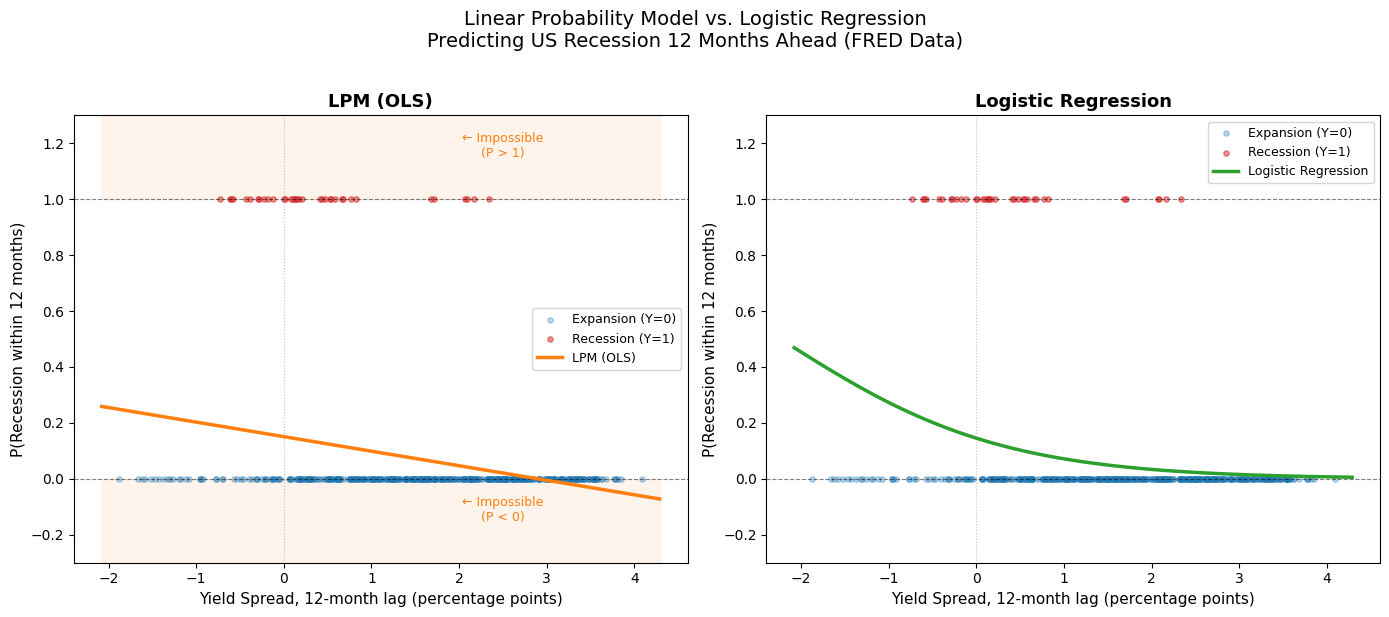

Figure saved as lpm_vs_logistic.png


In [9]:
# ------------------------------------------------------------
# Step 5: Side-by-side comparison plot — LPM vs. Logistic
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_RECESSION = '#d62728'   # Red for recession months
COLOR_EXPANSION = '#1f77b4'   # Blue for expansion months
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate recession and expansion observations
x_vals = df['yield_spread_lag12'].values
recession_mask = y == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[~recession_mask], y[~recession_mask],
               color=COLOR_EXPANSION, alpha=0.3, s=15, label='Expansion (Y=0)', zorder=2)
    ax.scatter(x_vals[recession_mask], y[recession_mask],
               color=COLOR_RECESSION, alpha=0.5, s=15, label='Recession (Y=1)', zorder=2)

    # Model prediction curve
    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel('Yield Spread, 12-month lag (percentage points)', fontsize=11)
    ax.set_ylabel('P(Recession within 12 months)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(spread_grid.ravel(), -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(2.5, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(2.5,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\nPredicting US Recession 12 Months Ahead (FRED Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as lpm_vs_logistic.png")

In [15]:
# ------------------------------------------------------------
# Part 2A: Extract and interpret the odds ratio
# ------------------------------------------------------------
# The logistic regression coefficient β₁ represents the change in LOG-ODDS
# for a one-unit increase in the yield spread.
#
# To get the ODDS RATIO, we exponentiate: OR = exp(β₁)
# If OR = 0.5, that means: "a 1pp increase in the spread cuts recession odds in half"

# Extract the coefficient (slope on yield_spread_lag12)
beta_1 = logit_model.coef_[0][0]

# TODO: Compute the odds ratio by exponentiating beta_1
odds_ratio = np.exp(beta_1)

# TODO: Compute the 95% confidence interval
# Hint: use statsmodels Logit for CIs — sklearn doesn't provide them by default
X_sm = sm.add_constant(df[['yield_spread_lag12']])  # statsmodels needs intercept added explicitly
logit_sm = sm.Logit(df['recession'], X_sm).fit(disp=False)  # disp=False suppresses iteration output

# Extract coefficient, SE, and 95% CI from the statsmodels result
coef_table = logit_sm.summary2().tables[1]
print("Statsmodels Logit summary:")
print(coef_table)

# TODO: Compute the odds ratio for the yield_spread_lag12 coefficient
# and its 95% CI by exponentiating the lower and upper confidence bounds
# Hint: coef_table.loc['yield_spread_lag12', ['Coef.', '[0.025', '0.975]']]
row = coef_table.loc['yield_spread_lag12']
or_point = np.exp(row['Coef.'])
or_lower = np.exp(row['[0.025'])
or_upper = np.exp(row['0.975]'])


print(f"\n{'='*50}")
print(f"Odds Ratio: {or_point:.4f}")
print(f"95% CI:     [{or_lower:.4f}, {or_upper:.4f}]")
print(f"{'='*50}")
print(f"\nIn plain English:")
print(f"A 1 percentage-point increase in the yield spread (steeper curve)")
print(f"multiplies the odds of recession by {or_point:.3f}.")
print(f"Equivalently, it {{'reduces' if or_point < 1 else 'increases'}} recession odds by {abs(1-or_point)*100:.1f}%.")

Statsmodels Logit summary:
                       Coef.  Std.Err.         z         P>|z|    [0.025  \
const              -1.760555  0.198092 -8.887577  6.245602e-19 -2.148808   
yield_spread_lag12 -0.809978  0.150846 -5.369585  7.891825e-08 -1.105630   

                      0.975]  
const              -1.372303  
yield_spread_lag12 -0.514326  

Odds Ratio: 0.4449
95% CI:     [0.3310, 0.5979]

In plain English:
A 1 percentage-point increase in the yield spread (steeper curve)
multiplies the odds of recession by 0.445.
Equivalently, it {'reduces' if or_point < 1 else 'increases'} recession odds by 55.5%.


In [17]:
# ------------------------------------------------------------
# Part 2B: Generate the recession probability time series
# ------------------------------------------------------------
# This is what the NY Fed publishes monthly: a time series of P(recession)
# 12 months ahead, based on the current yield spread.

# We use predict_proba() on the full dataset to get the fitted probability
# for each month in our sample.

# IMPORTANT REMINDER:
# .predict()         → returns class labels: array([0, 0, 1, 0, ...])
# .predict_proba()   → returns [[P(Y=0), P(Y=1)], ...] for each observation
# .predict_proba()[:, 1] → the probability of the POSITIVE class (recession)

# TODO: Generate predicted recession probabilities for the full dataset
df['recession_prob'] = logit_model.predict_proba(X)[:, 1]

# Verify: probabilities should be between 0 and 1
print(f"Min probability: {df['recession_prob'].min():.4f}")
print(f"Max probability: {df['recession_prob'].max():.4f}")
print(f"Mean probability: {df['recession_prob'].mean():.4f}")
print(f"Base rate (actual recession %): {df['recession'].mean():.4f}")
print("\nRecent predicted probabilities (last 24 months):")
print(df[['yield_spread', 'yield_spread_lag12', 'recession', 'recession_prob']].tail(24).round(4))

Min probability: 0.0066
Max probability: 0.4297
Mean probability: 0.0695
Base rate (actual recession %): 0.0695

Recent predicted probabilities (last 24 months):
            yield_spread  yield_spread_lag12  recession  recession_prob
2024-03-31         -1.26               -1.37        0.0          0.3348
2024-04-30         -0.77               -1.66        0.0          0.3877
2024-05-31         -0.95               -1.88        0.0          0.4297
2024-06-30         -1.12               -1.62        0.0          0.3802
2024-07-31         -1.32               -1.58        0.0          0.3727
2024-08-31         -1.30               -1.47        0.0          0.3526
2024-09-30         -0.92               -0.96        0.0          0.2667
2024-10-31         -0.36               -0.71        0.0          0.2298
2024-11-30         -0.40               -1.08        0.0          0.2857
2024-12-31          0.21               -1.52        0.0          0.3617
2025-01-31          0.27               -1.43  

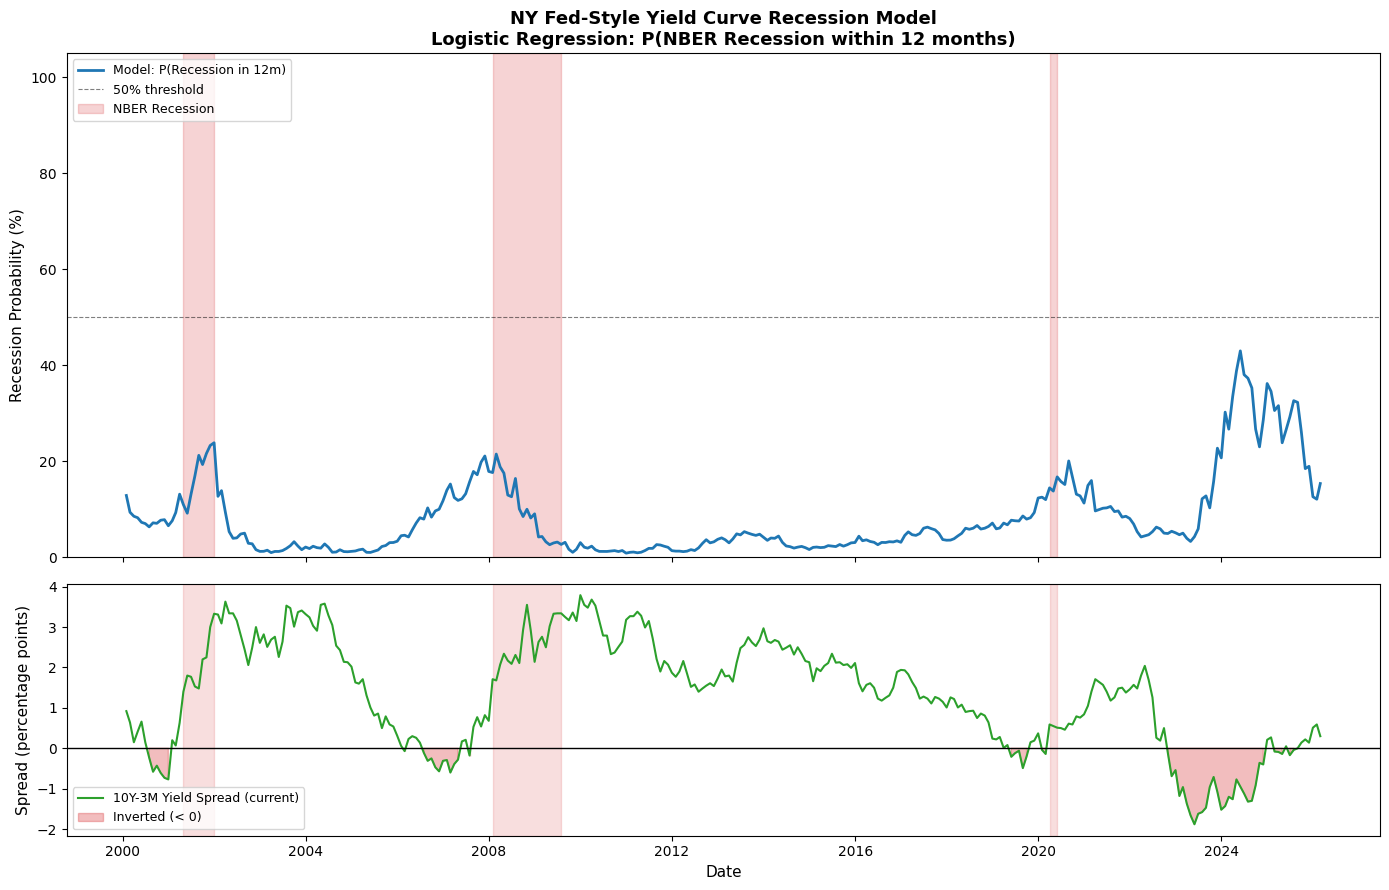

Figure saved as recession_probability_series.png


In [19]:
# ------------------------------------------------------------
# Part 2C: Plot the probability time series with NBER shading
# ------------------------------------------------------------
# This is the signature NY Fed chart style:
# - Blue line: model's predicted recession probability
# - Red shading: actual NBER recession periods

# Focus on 2000-present where the yield curve inversions are most interesting
df_plot = df['2000':].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

# --- Top panel: Recession probability ---
ax1.plot(df_plot.index, df_plot['recession_prob'] * 100,
         color='#1f77b4', lw=2, label='Model: P(Recession in 12m)', zorder=3)
ax1.axhline(50, color='black', lw=0.8, linestyle='--', alpha=0.5, label='50% threshold')

# TODO: Shade NBER recession periods
# Hint: find where df_plot['recession'] == 1, identify contiguous blocks,
# and use ax1.axvspan(start_date, end_date, ...) for each block.
#
# One approach: use a helper to find start/end of each recession block
def get_recession_bands(df_in):
    """Return list of (start_date, end_date) tuples for NBER recession periods."""
    in_recession = False
    bands = []
    start = None
    for date, val in df_in['recession'].items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            bands.append((start, date))
            in_recession = False
    if in_recession:  # Handle case where sample ends in recession
        bands.append((start, df_in.index[-1]))
    return bands

# TODO: Call get_recession_bands() and shade each band on ax1 using ax1.axvspan()
# Use: color='#d62728', alpha=0.2, label='NBER Recession' (only label first band)
recession_bands = get_recession_bands(df_plot)
for i, (start, end) in enumerate(recession_bands):
    label = 'NBER Recession' if i == 0 else ""
    ax1.axvspan(start, end, color=COLOR_RECESSION, alpha=0.2, label=label, zorder=1)

ax1.set_ylabel('Recession Probability (%)', fontsize=11)
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_title('NY Fed-Style Yield Curve Recession Model\nLogistic Regression: P(NBER Recession within 12 months)',
              fontsize=13, fontweight='bold')

# --- Bottom panel: Yield spread ---
ax2.plot(df_plot.index, df_plot['yield_spread'],
         color='#2ca02c', lw=1.5, label='10Y-3M Yield Spread (current)')
ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.fill_between(df_plot.index, df_plot['yield_spread'], 0,
                  where=(df_plot['yield_spread'] < 0),
                  color='#d62728', alpha=0.3, label='Inverted (< 0)')
for start, end in recession_bands:
    ax2.axvspan(start, end, color='#d62728', alpha=0.15)

ax2.set_ylabel('Spread (percentage points)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('recession_probability_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recession_probability_series.png")

### Answers to the Questions

**Question 1 — The 2022–2024 Inversion**
When the yield curve was at its most inverted around late 2022 / early 2023 (specifically May 2023), the model predicted a recession probability of about **43.0%**. This corresponds to a lagged yield spread of -1.88 percentage points.

**Question 2 — Interpreting a Miss**
When a model predicts an elevated recession risk, but no NBER recession follows, it shows that probabilities are certain. 40% or 80% probability of recession still means there's a significant chancethat a recession won't occur. The model isn't wrong here, it is just showing that it is uncertain.

Question 3 — 2006–2007 Performance**
In 2006-2007, the model showed more probabilities of recession. For example, in late 2007, probabilities were above 15-20%, and they kept going up into 2008 before the real start of the Great Recession. The model performed relatively well in her, because it signaled a increase in recession risk before the actual recession.